In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

# 构造 120 天日期
n_days = 120
dates = pd.date_range(start="2024-01-01", periods=n_days, freq="D")

# 时间索引
t = np.arange(n_days)

# 趋势：销量整体慢慢上升
trend = 50 + 0.2 * t

# 周期性：每 7 天出现一次波动，模拟一周周期
seasonality = 8 * np.sin(2 * np.pi * t / 7)

# 噪声：随机波动
noise = np.random.normal(loc=0, scale=3, size=n_days)

# 最终销量
sales = trend + seasonality + noise

df = pd.DataFrame({
    "date": dates,
    "sales": sales
})

df.head()

,date,sales
0,2024-01-01,51.490142
1,2024-01-02,56.039859
2,2024-01-03,60.142489
3,2024-01-04,58.640159
4,2024-01-05,46.626470


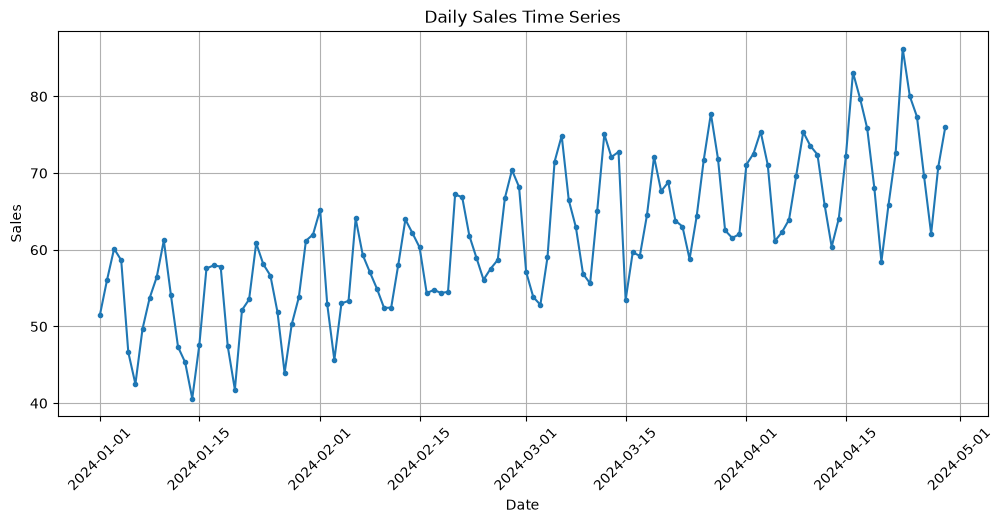

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["sales"], marker="o", markersize=3)
plt.title("Daily Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

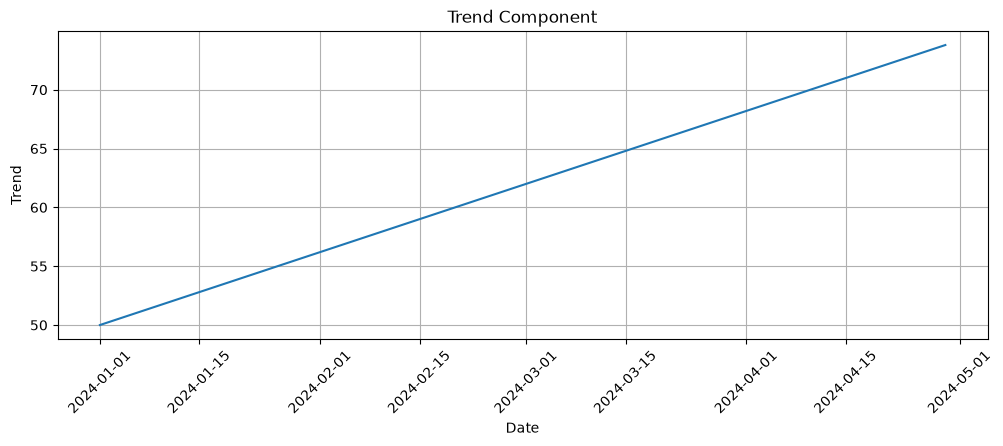

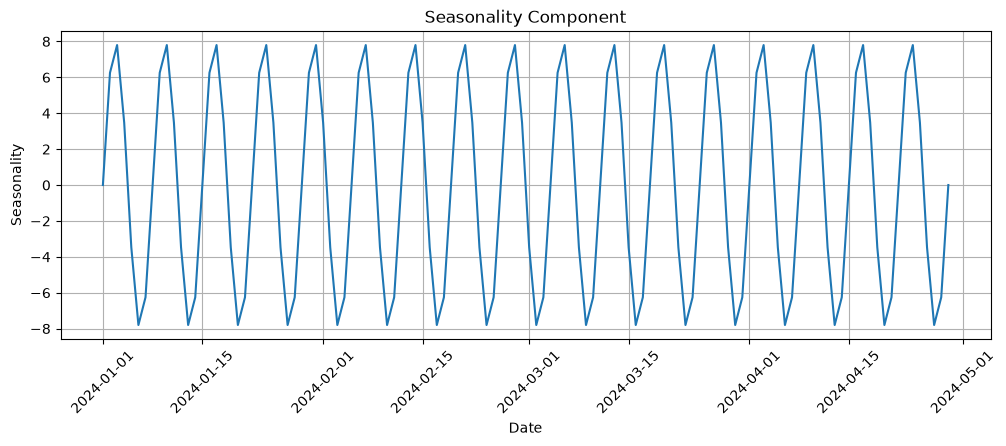

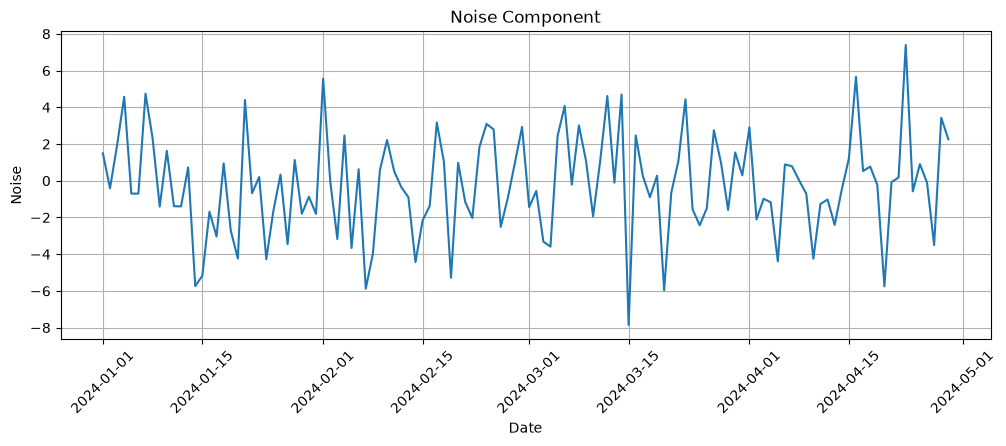

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(df["date"], trend)
plt.title("Trend Component")
plt.xlabel("Date")
plt.ylabel("Trend")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df["date"], seasonality)
plt.title("Seasonality Component")
plt.xlabel("Date")
plt.ylabel("Seasonality")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df["date"], noise)
plt.title("Noise Component")
plt.xlabel("Date")
plt.ylabel("Noise")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [5]:
df["rolling_mean_7"] = df["sales"].rolling(window=7).mean()

df.head(10)

,date,sales,rolling_mean_7
0,2024-01-01,51.490142,NaN
1,2024-01-02,56.039859,NaN
2,2024-01-03,60.142489,NaN
3,2024-01-04,58.640159,NaN
4,2024-01-05,46.626470,NaN
5,2024-01-06,42.498166,NaN
6,2024-01-07,49.682987,52.160039
7,2024-01-08,53.702304,52.476062
8,2024-01-09,56.446229,52.534115
9,2024-01-10,61.227103,52.689060


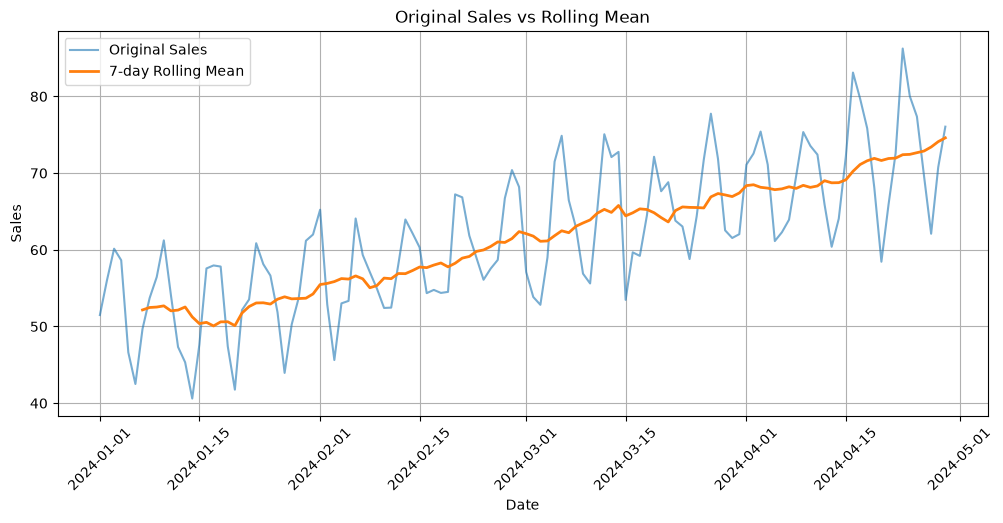

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["sales"], label="Original Sales", alpha=0.6)
plt.plot(df["date"], df["rolling_mean_7"], label="7-day Rolling Mean", linewidth=2)
plt.title("Original Sales vs Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [7]:

train_size = int(len(df) * 0.8)

train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

print("训练集大小：", len(train_df))
print("测试集大小：", len(test_df))

print("训练集时间范围：", train_df["date"].min(), "到", train_df["date"].max())
print("测试集时间范围：", test_df["date"].min(), "到", test_df["date"].max())

训练集大小： 96
测试集大小： 24
训练集时间范围： 2024-01-01 00:00:00 到 2024-04-05 00:00:00
测试集时间范围： 2024-04-06 00:00:00 到 2024-04-29 00:00:00


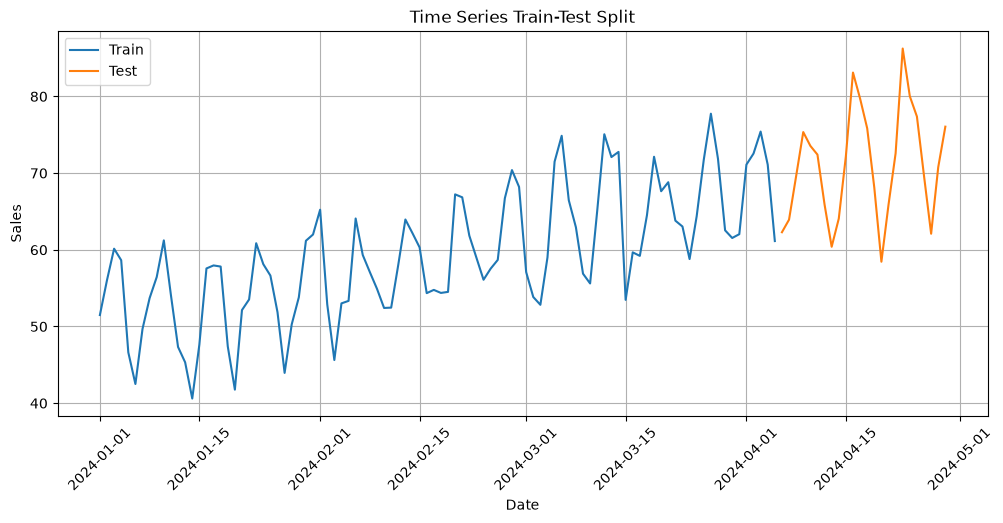

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(train_df["date"], train_df["sales"], label="Train")
plt.plot(test_df["date"], test_df["sales"], label="Test")
plt.title("Time Series Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [9]:
df["lag_1"] = df["sales"].shift(1)
df["lag_2"] = df["sales"].shift(2)
df["lag_7"] = df["sales"].shift(7)

df.head(10)

,date,sales,rolling_mean_7,lag_1,lag_2,lag_7
0,2024-01-01,51.490142,NaN,NaN,NaN,NaN
1,2024-01-02,56.039859,NaN,51.490142,NaN,NaN
2,2024-01-03,60.142489,NaN,56.039859,51.490142,NaN
3,2024-01-04,58.640159,NaN,60.142489,56.039859,NaN
4,2024-01-05,46.626470,NaN,58.640159,60.142489,NaN
5,2024-01-06,42.498166,NaN,46.626470,58.640159,NaN
6,2024-01-07,49.682987,52.160039,42.498166,46.626470,NaN
7,2024-01-08,53.702304,52.476062,49.682987,42.498166,51.490142
8,2024-01-09,56.446229,52.534115,53.702304,49.682987,56.039859
9,2024-01-10,61.227103,52.689060,56.446229,53.702304,60.142489


In [10]:
df[["date", "sales", "lag_1", "lag_2", "lag_7"]].head(12)

,date,sales,lag_1,lag_2,lag_7
0,2024-01-01,51.490142,NaN,NaN,NaN
1,2024-01-02,56.039859,51.490142,NaN,NaN
2,2024-01-03,60.142489,56.039859,51.490142,NaN
3,2024-01-04,58.640159,60.142489,56.039859,NaN
4,2024-01-05,46.626470,58.640159,60.142489,NaN
5,2024-01-06,42.498166,46.626470,58.640159,NaN
6,2024-01-07,49.682987,42.498166,46.626470,NaN
7,2024-01-08,53.702304,49.682987,42.498166,51.490142
8,2024-01-09,56.446229,53.702304,49.682987,56.039859
9,2024-01-10,61.227103,56.446229,53.702304,60.142489


In [11]:
feature_df = df.copy()

feature_df["rolling_mean_3"] = feature_df["sales"].shift(1).rolling(window=3).mean()
feature_df["rolling_mean_7"] = feature_df["sales"].shift(1).rolling(window=7).mean()

feature_df = feature_df.dropna()

feature_df.head()

,date,sales,rolling_mean_7,lag_1,lag_2,lag_7,rolling_mean_3
7,2024-01-08,53.702304,52.160039,49.682987,42.498166,51.490142,46.269207
8,2024-01-09,56.446229,52.476062,53.702304,49.682987,56.039859,48.627819
9,2024-01-10,61.227103,52.534115,56.446229,53.702304,60.142489,53.277173
10,2024-01-11,54.080817,52.689060,61.227103,56.446229,58.640159,57.125212
11,2024-01-12,47.331741,52.037725,54.080817,61.227103,46.626470,57.251383


In [12]:
X = feature_df[["lag_1", "lag_2", "lag_7", "rolling_mean_3", "rolling_mean_7"]]
y = feature_df["sales"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (113, 5)
y shape: (113,)


,lag_1,lag_2,lag_7,rolling_mean_3,rolling_mean_7
7,49.682987,42.498166,51.490142,46.269207,52.160039
8,53.702304,49.682987,56.039859,48.627819,52.476062
9,56.446229,53.702304,60.142489,53.277173,52.534115
10,61.227103,56.446229,58.640159,57.125212,52.689060
11,54.080817,61.227103,46.626470,57.251383,52.037725


In [13]:
test_df = test_df.copy()

# 第一个测试点，用训练集最后一天的销量预测
last_train_value = train_df["sales"].iloc[-1]

# 后面的测试点，用前一天真实值预测
naive_preds = [last_train_value] + list(test_df["sales"].iloc[:-1])

test_df["naive_pred"] = naive_preds

test_df.head()

,date,sales,rolling_mean_7,naive_pred
96,2024-04-06,62.288938,67.947073,61.138385
97,2024-04-07,63.928514,68.217350,62.288938
98,2024-04-08,69.615340,68.004407,63.928514
99,2024-04-09,75.350890,68.404750,69.615340
100,2024-04-10,73.553311,68.138589,75.350890


In [14]:
y_true = test_df["sales"].values
y_pred = test_df["naive_pred"].values

mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

print("Naive Baseline MAE:", mae)
print("Naive Baseline RMSE:", rmse)

Naive Baseline MAE: 5.936219550556459
Naive Baseline RMSE: 6.700592036450539


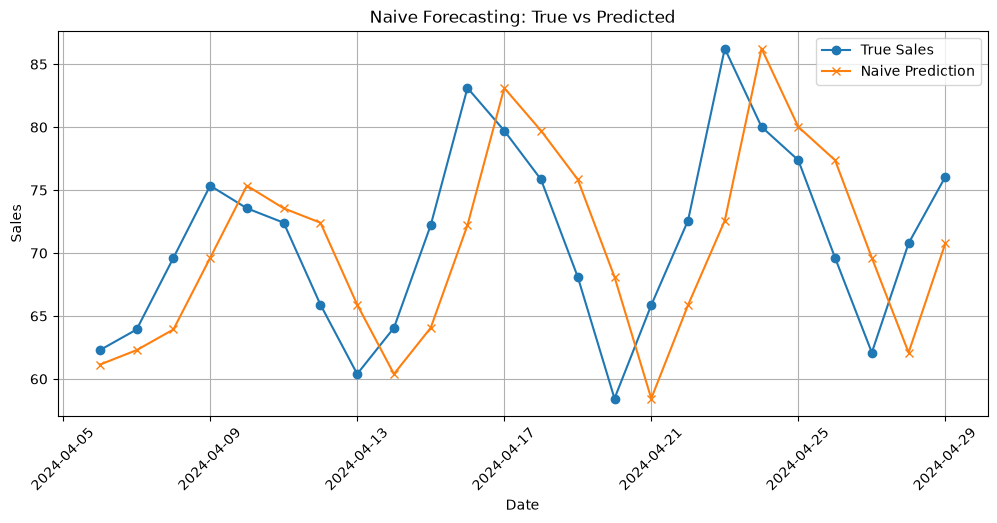

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(test_df["date"], test_df["sales"], marker="o", label="True Sales")
plt.plot(test_df["date"], test_df["naive_pred"], marker="x", label="Naive Prediction")
plt.title("Naive Forecasting: True vs Predicted")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

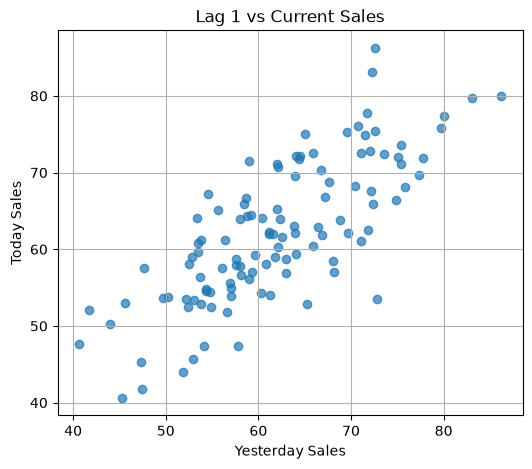

In [16]:
plt.figure(figsize=(6, 5))
plt.scatter(feature_df["lag_1"], feature_df["sales"], alpha=0.7)
plt.title("Lag 1 vs Current Sales")
plt.xlabel("Yesterday Sales")
plt.ylabel("Today Sales")
plt.grid(True)
plt.show()

In [17]:
corr_lag_1 = feature_df["lag_1"].corr(feature_df["sales"])
corr_lag_2 = feature_df["lag_2"].corr(feature_df["sales"])
corr_lag_7 = feature_df["lag_7"].corr(feature_df["sales"])

print("lag_1 和 sales 的相关系数：", corr_lag_1)
print("lag_2 和 sales 的相关系数：", corr_lag_2)
print("lag_7 和 sales 的相关系数：", corr_lag_7)

lag_1 和 sales 的相关系数： 0.7672724051133503
lag_2 和 sales 的相关系数： 0.4558013584789431
lag_7 和 sales 的相关系数： 0.9165091544003974
